In [5]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated, List
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from langgraph.graph.message import add_messages
import operator

In [6]:
load_dotenv()

True

In [29]:
model = ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite")

In [8]:
class ChatState(TypedDict):
    messages: Annotated[List[BaseMessage], add_messages,"The list of messages in the conversation so far."]

In [15]:
def chat_node(state: ChatState) -> ChatState:
    messages = state["messages"]
    response = model.invoke(messages)
    return {'messages': messages + [response]}

In [16]:
graph = StateGraph(ChatState)

graph.add_node("Chat Node",chat_node)
graph.add_edge(START, "Chat Node")
graph.add_edge("Chat Node", END)

workflow = graph.compile()

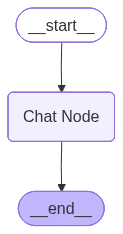

In [17]:
workflow

In [20]:
initial_state = {"messages": [HumanMessage(content="Hello, Explain what are PEFT?")]}
result = workflow.invoke(initial_state)
print(result["messages"][-1].content)

Hello! Let's break down **PEFT** in an easy-to-understand way.

**PEFT stands for Parameter-Efficient Fine-Tuning.**

It's a collection of techniques designed to adapt large pre-trained language models (LLMs) to new, specific tasks or datasets **without having to retrain or store the entire massive model.**

---

### The Problem PEFT Solves

Imagine you have a gigantic, incredibly knowledgeable chef (a Large Language Model like GPT-4 or Llama 2). This chef knows how to cook every cuisine imaginable.

Now, you open a new restaurant that specializes in *just one specific dish* (your downstream task, e.g., customer support chatbot, medical text summarizer).

**The traditional way to "fine-tune" this chef would be:**

1.  **Retrain the entire chef:** Make them re-learn *everything* about cooking, but with a focus on your specific dish.
2.  **This is incredibly expensive:**
    *   **Computationally:** Requires immense resources (many GPUs, lots of time).
    *   **Storage:** You'd need to 

In [30]:
while True:
    import time
    user_input = input("You: ")
    print(f"User input: {user_input}")
    if user_input.strip().lower() in ["exit", "quit","bye"]:
        break
    response = workflow.invoke({"messages": [HumanMessage(content=user_input)]})
    print(f"AI: {response['messages'][-1].content}")
    time.sleep(2)

User input: hi myself harsh
AI: Hi Harsh! It's nice to meet you. How can I help you today?
User input: what was my name
AI: I do not have access to your personal information, including your name. I am a large language model and do not have memory of past conversations or personal details about users.
User input: but i just told you my name
AI: I apologize! It seems I missed that information. My apologies for the oversight.

Please, could you remind me of your name? I'm still learning and sometimes I have trouble keeping track of everything in a conversation.
User input: harsh
AI: "Harsh" is a word that describes something that is **unpleasantly rough, severe, or extreme**. It can be applied to a wide range of things, both physical and abstract.

Here's a breakdown of its common meanings and contexts:

**Physical Harshness:**

*   **Texture/Surface:** Rough, abrasive, not smooth.
    *   *Example:* The **harsh** sandpaper scratched my skin.
    *   *Example:* The **harsh** desert landsc